# Statistical and PCA Analysis
### This notebook will perfrom an SVM analysis of the cleaned and formated data

March 5th, 2025

Maxime Bouthillier

In [120]:
import pandas as pd
import os 
from joblib import load
from sklearn import svm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

In [121]:
# Setting the Directory
directory = '/Users/maxb/Library/CloudStorage/OneDrive-UniversityofWaterloo/Hospital Research/Datasets/MIMI-III_Full'
os.chdir(directory)

# Loading dataframe from Pipeline notebook
df = load("Master_Dataframe_reduced.joblib") # Reduced Dataset


# Dropping the unnecessary columns
# df = df.drop(['inputs', 'events', 'prescriptions', 'procedures', 'labs', 'subject_id', 'admittime', 'dischtime'], axis=1) # Non-reduced
df = df.drop(['subject_id', 'admittime', 'dischtime'], axis=1) # Reduced

In [122]:
# Altering column values to integer (categorical) or float objects
for col, col_values in df.items():
    if df[col].dtype == ('O'):
        df[col] = df[col].astype('category').cat.codes

    elif df[col].dtype == ('<m8[ns]'):
        df[col] = df[col].dt.total_seconds()

# PCA Recued Spaces

### Time in Seconds

In [123]:
df['los'] = df['los']*(60**2*24) # making the LOS time in seconds

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_s = PCA(n_components=2)
X_pca_s = pca_s.fit_transform(X)

### Time in minutes

In [124]:
# Seconds to minutes
df['los'] = df['los']/60
df['admit_duration'] = df['admit_duration']/60

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_m = PCA(n_components=2)
X_pca_m = pca_m.fit_transform(X)

### Time in hours

In [125]:
# Minutes to hours
df['los'] = df['los']/60
df['admit_duration'] = df['admit_duration']/60

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_h = PCA(n_components=2)
X_pca_h = pca_h.fit_transform(X)

### Time in days

In [126]:
# Hours to days
df['los'] = df['los']/24
df['admit_duration'] = df['admit_duration']/24

y = df['read_flag']
X = df.drop('read_flag', axis=1)

pca_d = PCA(n_components=2)
X_pca_d = pca_d.fit_transform(X)

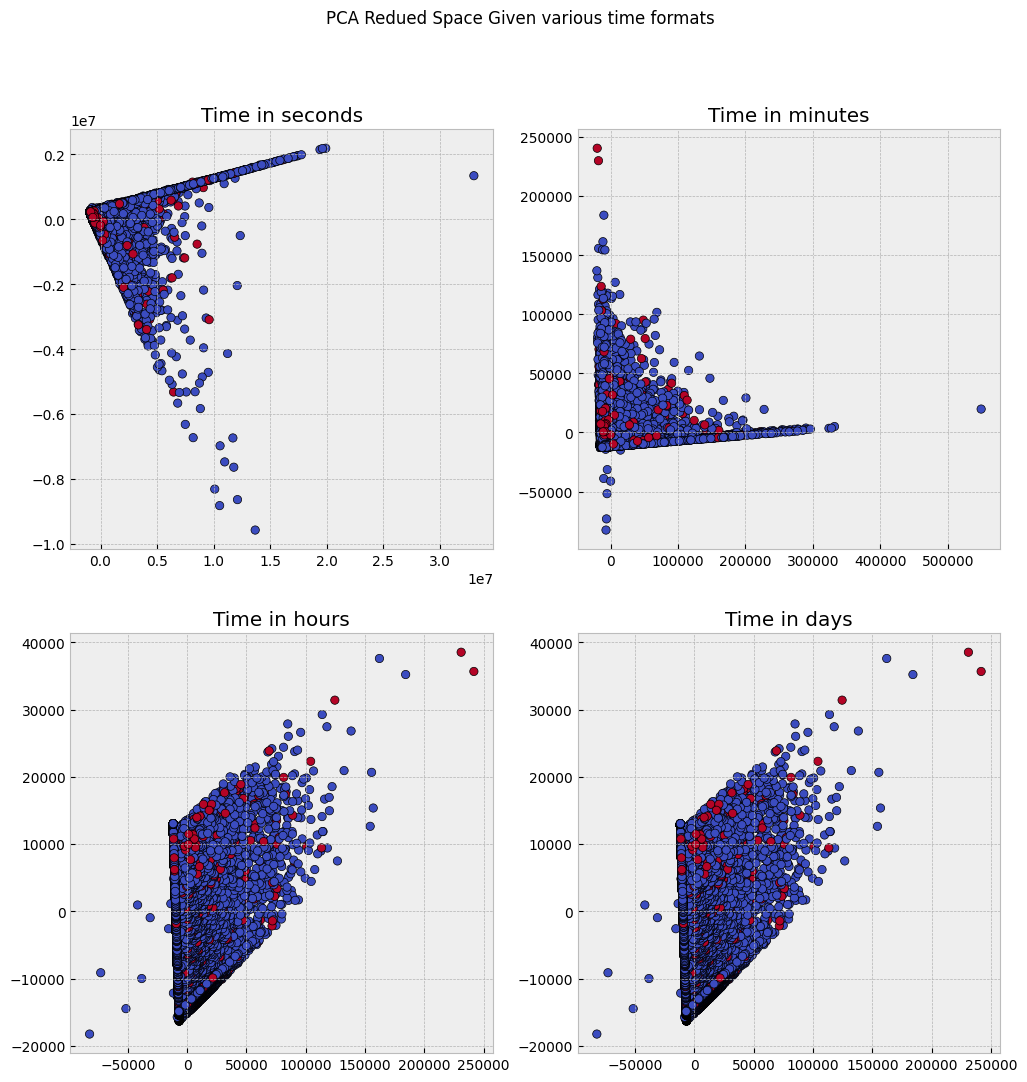

In [127]:
# Plotting PCA
fig, ax = plt.subplots(2,2, figsize=(12,12))

fig.suptitle("PCA Redued Space Given various time formats")

ax[0,0].scatter(X_pca_s[:, 0], X_pca_s[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[0,0].set_title("Time in seconds")

ax[0,1].scatter(X_pca_m[:, 0], X_pca_m[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[0,1].set_title("Time in minutes")

ax[1,0].scatter(X_pca_h[:, 0], X_pca_h[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[1,0].set_title("Time in hours")

ax[1,1].scatter(X_pca_d[:, 0], X_pca_d[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
ax[1,1].set_title("Time in days")

plt.style.use('bmh')
plt.show()

In [128]:
feature_names = df.columns.drop('read_flag')
components = [pd.DataFrame(pca_s.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_s.n_components_)]),
              pd.DataFrame(pca_m.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_m.n_components_)]),
              pd.DataFrame(pca_h.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_h.n_components_)]),
              pd.DataFrame(pca_d.components_, columns=feature_names, index=[f'PC{i+1}' for i in range(pca_d.n_components_)])]
components_df = pd.concat(components)
components_df['pca_type'] = ['seconds']*2 + ['minutes']*2 + ['hours']*2 + ['days']*2
display(components_df)

,admission_type,admission_location,discharge_location,insurance,marital_status,ethnicity,admit_duration,ed_duration,gender,dob,los,pca_type
PC1,4.961541e-08,-6.252603e-08,5.260756e-07,-7.087497e-09,-1.996905e-08,-1.940180e-08,0.770409,-0.000495,-2.046124e-09,0.000465,0.637549,seconds
PC2,2.917205e-07,-2.032436e-07,-1.533374e-06,1.517662e-07,-1.205871e-07,-6.582841e-07,-0.637544,-0.003686,-1.526025e-08,0.003268,0.770398,seconds
PC1,3.172142e-06,-2.822897e-06,3.005828e-05,-2.530543e-07,-1.261901e-06,-1.380600e-06,0.768027,-0.048984,-8.095200e-08,0.034149,0.637628,minutes
PC2,-5.901477e-06,-4.811387e-05,5.333198e-05,-6.863517e-06,1.172190e-06,-1.346624e-05,0.087179,0.981577,-1.864006e-06,-0.168773,-0.020563,minutes
PC1,-6.083814e-06,-4.790484e-05,4.749203e-05,-6.682070e-06,1.239990e-06,-1.390705e-05,-0.000579,0.985342,-1.866948e-06,-0.170581,-0.001685,hours
PC2,2.829481e-05,-1.735220e-05,-1.383588e-04,1.181300e-05,-1.463950e-05,-1.696194e-04,0.001308,0.170587,1.298284e-06,0.985336,0.003487,hours
PC1,-6.083555e-06,-4.790538e-05,4.749395e-05,-6.682089e-06,1.239877e-06,-1.390749e-05,-0.000024,0.985344,-1.866967e-06,-0.170578,-0.000070,days
PC2,2.829382e-05,-1.734907e-05,-1.383758e-04,1.181345e-05,-1.463913e-05,-1.696210e-04,0.000054,0.170578,1.298446e-06,0.985344,0.000145,days
